In [1]:
!pip install gensim

In [6]:
!pip install git+https://github.com/haven-jeon/PyKoSpacing.git

  Cloning https://github.com/haven-jeon/PyKoSpacing.git to /tmp/pip-req-build-7ef66lv1
  Running command git clone --filter=blob:none --quiet https://github.com/haven-jeon/PyKoSpacing.git /tmp/pip-req-build-7ef66lv1
  Resolved https://github.com/haven-jeon/PyKoSpacing.git to commit b32a889cbd10b006d2f4aba118f0cd5b677e2979
  Preparing metadata (setup.py) ... done
  Using cached argparse-1.4.0-py2.py3-none-any.whl.metadata (2.8 kB)
Using cached argparse-1.4.0-py2.py3-none-any.whl (23 kB)


In [2]:
!pip install -q nltk

In [3]:
pip install konlpy gensim torch pandas

# 한국어 챗봇 학습 흐름

1. 필요한 라이브러리와 데이터를 준비합니다.
2. MeCab 형태소 분석으로 문장을 정리하고, 학습 / 검증 / 테스트 데이터로 나눕니다.
3. Word2Vec을 이용해 학습 문장을 일부 치환하여 학습 데이터를 늘리고 문장을 토큰 ID 텐서로 변환합니다.
4. 인코더와 디코더로 구성된 Transformer를 만들고 패딩 및 미래 토큰 마스크를 적용합니다.
5. 정답 토큰을 한 칸씩 밀어 학습하면서 검증 손실이 가장 낮은 모델을 저장합니다.
6. 저장한 모델로 문장을 생성한 뒤 BLEU, Perplexity, Distinct 점수와 샘플 출력으로 결과를 확인합니다.

In [4]:
import numpy as np
import pandas as pd
import torch
import nltk
import gensim

print(np.__version__)
print(pd.__version__)
print(torch.__version__)
print(nltk.__version__)
print(gensim.__version__)

2.1.3
2.2.3
2.11.0+cu128
3.9.1
4.4.0


## 1. 데이터 준비

공개된 한국어 일상 대화 데이터셋을 내려받고 질문(`Q`)과 답변(`A`) 열을 확인합니다.

* [songys/Chatbot_data](https://github.com/songys/Chatbot_data)

In [5]:
import os
import urllib.request

# 공개 데이터셋이 없으면 먼저 내려받습니다.
url = 'https://raw.githubusercontent.com/songys/Chatbot_data/master/ChatbotData.csv'
csv_filename = 'ChatbotData.csv'

if not os.path.exists(csv_filename):
    print(f"Downloading {csv_filename} ...")
    urllib.request.urlretrieve(url, csv_filename)
    print("Download complete.")

# 질문과 답변이 들어 있는 CSV를 읽습니다.
data = pd.read_csv(csv_filename)

print("데이터 크기:", data.shape)
data.head()

Download complete.
데이터 크기: (11823, 3)


,Q,A,label
0,12시 땡!,하루가 또 가네요.,0
1,1지망 학교 떨어졌어,위로해 드립니다.,0
2,3박4일 놀러가고 싶다,여행은 언제나 좋죠.,0
3,3박4일 정도 놀러가고 싶다,여행은 언제나 좋죠.,0
4,PPL 심하네,눈살이 찌푸려지죠.,0


## 2. 데이터 살펴보기

데이터의 크기와 열 구성을 확인해 전처리 전에 기본적인 형태를 파악합니다.

In [6]:
print('========== data.shape ==========')
print(data.shape, '\n')
print('========== data.info() ==========')
print(data.info())

========== data.shape ==========
(11823, 3) 

========== data.info() ==========
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11823 entries, 0 to 11822
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   Q       11823 non-null  object
 1   A       11823 non-null  object
 2   label   11823 non-null  int64 
dtypes: int64(1), object(2)
memory usage: 277.2+ KB
None


## 3. 전처리와 데이터 구성

문장을 정규화하고 MeCab으로 형태소 단위로 나눈 뒤 중복, 빈 문장, 지나치게 긴 문장을 제외합니다. 이후 학습, 검증, 테스트 세트로 나누어 모델 입력에 사용할 형태로 준비합니다.

In [7]:
# KoNLPy 설치
!pip install -q konlpy

# MeCab-ko + mecab-ko-dic 설치
!git clone -q https://github.com/SOMJANG/Mecab-ko-for-Google-Colab.git
%cd Mecab-ko-for-Google-Colab
!bash install_mecab-ko_on_colab_light_220429.sh
%cd /content

fatal: destination path 'Mecab-ko-for-Google-Colab' already exists and is not an empty directory.
/content/Mecab-ko-for-Google-Colab
Installing konlpy.....
Done
Installing mecab-0.996-ko-0.9.2.tar.gz.....
from https://bitbucket.org/eunjeon/mecab-ko/downloads/mecab-0.996-ko-0.9.2.tar.gz
--2026-09-11 06:11:50--  https://bitbucket.org/eunjeon/mecab-ko/downloads/mecab-0.996-ko-0.9.2.tar.gz
Resolving bitbucket.org (bitbucket.org)... 185.166.143.49, 185.166.143.48, 185.166.143.50, ...
Connecting to bitbucket.org (bitbucket.org)|185.166.143.49|:443... connected.
HTTP request sent, awaiting response... 404 Not Found
2026-09-11 06:11:50 ERROR 404: Not Found.

Done
Unpacking mecab-0.996-ko-0.9.2.tar.gz.......
Done
Change Directory to mecab-0.996-ko-0.9.2.......
install_mecab-ko_on_colab_light_220429.sh: line 23: cd: mecab-0.996-ko-0.9.2/: No such file or directory
installing mecab-0.996-ko-0.9.2.tar.gz........
configure
make
make check
make install
ldconfig
Done
Change Directory to /content
from

In [8]:
from konlpy.tag import Mecab

mecab = Mecab()

print(mecab.morphs("안녕하세요. 저는 한국어 형태소 분석을 공부하고 있습니다."))
print(mecab.pos("안녕하세요. 저는 한국어 형태소 분석을 공부하고 있습니다."))

['안녕', '하', '세요', '.', '저', '는', '한국어', '형태소', '분석', '을', '공부', '하', '고', '있', '습니다', '.']
[('안녕', 'NNG'), ('하', 'XSV'), ('세요', 'EP+EF'), ('.', 'SF'), ('저', 'NP'), ('는', 'JX'), ('한국어', 'NNG'), ('형태소', 'NNG'), ('분석', 'NNG'), ('을', 'JKO'), ('공부', 'NNG'), ('하', 'XSV'), ('고', 'EC'), ('있', 'VX'), ('습니다', 'EF'), ('.', 'SF')]


In [9]:
# label 컬럼은 제외
data = data.drop(['label'], axis=1)

In [10]:
import re
import random
from collections import Counter

import pandas as pd
import torch
from torch.nn.utils.rnn import pad_sequence
from konlpy.tag import Mecab
from gensim.models import KeyedVectors

DATA_PATH = "/content/ChatbotData.csv"
WORD2VEC_PATH = "/content/ko_converted.bin"
MAX_LEN = 0  # 토큰 길이 제한은 뒤에서 길이 분포를 보고 결정

data = pd.read_csv(DATA_PATH)
questions = data["Q"].tolist()
answers = data["A"].tolist()

### Word2Vec 파일 형식 참고

기존 Word2Vec 파일이 오래된 Gensim 형식으로 저장되어 있어 최신 Gensim에서 바로 읽히지 않을 수 있습니다. 이 경우 구버전 환경에서 `save_word2vec_format()`으로 범용 형식으로 변환한 뒤 여기서 `load_word2vec_format()`으로 불러옵니다.

In [11]:
def preprocess_sentence(sentence: str) -> str:
    """영문자를 소문자로 바꾸고 필요한 문자만 남겨 문장을 정리합니다."""
    sentence = sentence.lower()

    # 한글, 영문, 숫자와 주요 문장부호만 남깁니다.
    sentence = re.sub(r"[^가-힣a-z0-9?.!,']+", " ", sentence)

    # 연속된 공백을 하나로 줄입니다.
    sentence = re.sub(r"\s+", " ", sentence).strip()

    return sentence

In [12]:
def build_corpus(src_data, tgt_data, tokenize_fn, max_len=MAX_LEN):
    """
    src_data, tgt_data : 소스/타겟 문장 리스트 (같은 인덱스끼리 병렬 쌍)
    tokenize_fn         : 토큰화 함수 (예: mecab.morphs)
    max_len              : 토큰 개수 상한. 소스 또는 타겟 중 하나라도 초과하면 그 쌍 전체 제외

    - 소스는 소스끼리, 타겟은 타겟끼리 독립적으로 중복을 검사합니다.
      (쌍을 기준으로 검사하지 않음 — 한쪽만 중복이어도 그 쌍은 제외됩니다)
    - src_corpus, tgt_corpus 는 끝까지 서로 인덱스가 맞는 병렬 쌍을 유지합니다.
    """
    src_corpus = []
    tgt_corpus = []

    seen_src = set()
    seen_tgt = set()

    for src, tgt in zip(src_data, tgt_data):
        src_clean = preprocess_sentence(src)
        tgt_clean = preprocess_sentence(tgt)

        src_tokens = tokenize_fn(src_clean)
        tgt_tokens = tokenize_fn(tgt_clean)

        if len(src_tokens) == 0 or len(tgt_tokens) == 0:
            continue
        if len(src_tokens) > max_len or len(tgt_tokens) > max_len:
            continue

        src_key = " ".join(src_tokens)
        tgt_key = " ".join(tgt_tokens)

        # 소스 또는 타겟 중 하나라도 이미 등장했다면 이 쌍은 제외
        if src_key in seen_src or tgt_key in seen_tgt:
            continue

        seen_src.add(src_key)
        seen_tgt.add(tgt_key)

        src_corpus.append(src_tokens)
        tgt_corpus.append(tgt_tokens)

    return src_corpus, tgt_corpus

In [13]:
from sklearn.model_selection import train_test_split

train_questions, test_questions, train_answers, test_answers = train_test_split(questions, answers, test_size=0.05, random_state=42)

In [14]:
train_questions, val_questions, train_answers, val_answers = train_test_split(train_questions, train_answers, test_size=0.1, random_state=42)

In [15]:
# 적당한 MAX_LEN 탐색
# mecab.morphs로 실제 토큰화했을 때의 길이 분포를 확인
import numpy as np

q_lengths = []
a_lengths = []

for q, a in zip(train_questions, train_answers):
    q_tokens = mecab.morphs(preprocess_sentence(q))
    a_tokens = mecab.morphs(preprocess_sentence(a))

    q_lengths.append(len(q_tokens))          # 질문에는 <start>/<end>를 붙이지 않음
    a_lengths.append(len(a_tokens) + 2)       # 답변은 <start> + tokens + <end>

q_lengths = np.array(q_lengths)
a_lengths = np.array(a_lengths)

print("질문 토큰 길이")
print("평균:", q_lengths.mean())
print("최대:", q_lengths.max())
print("95%:", np.percentile(q_lengths, 95))
print("99%:", np.percentile(q_lengths, 99))

print("\n답변 토큰 길이 (<start>/<end> 포함)")
print("평균:", a_lengths.mean())
print("최대:", a_lengths.max())
print("95%:", np.percentile(a_lengths, 95))
print("99%:", np.percentile(a_lengths, 99))

# 질문/답변 중 더 긴 쪽의 95~99 percentile 정도를 MAX_LEN으로 채택
MAX_LEN = int(max(np.percentile(q_lengths, 99), np.percentile(a_lengths, 99)))
print("\n선택된 MAX_LEN:", MAX_LEN)

que_corpus, ans_corpus = build_corpus(train_questions, train_answers, mecab.morphs, max_len=MAX_LEN)

print(f"[build_corpus] 질문 개수: {len(que_corpus)}, 답변 개수: {len(ans_corpus)}")
print("샘플 질문 토큰:", que_corpus[:2])
print("샘플 답변 토큰:", ans_corpus[:2])

질문 토큰 길이
평균: 7.031958048877016
최대: 32
95%: 14.0
99%: 18.0

답변 토큰 길이 (<start>/<end> 포함)
평균: 10.381715642623924
최대: 42
95%: 17.0
99%: 22.0

선택된 MAX_LEN: 22
[build_corpus] 질문 개수: 6916, 답변 개수: 6916
샘플 질문 토큰: [['차단', '여부', '를', '어찌', '아', '시', '나', '?', '??'], ['매달렸', '다', '차였', '어']]
샘플 답변 토큰: [['그건', '중요', '하', '지', '않', '아요', '.', '신경', '을', '덜', '어', '보', '세요', '.'], ['그래도', '미련', '은', '없', '을', '거', '예요', '.']]


In [16]:
# Word2Vec의 유사 단어 치환으로 질문과 답변 데이터를 각각 한 번씩 증강합니다.
word2vec = KeyedVectors.load_word2vec_format(WORD2VEC_PATH, binary=True)


def lexical_sub(tokens, word2vec_model):
    """
    토큰 리스트에서 Word2Vec에 등록된 단어 하나를 골라 가장 유사한 단어로 바꿉니다.
    치환할 단어가 없으면 None을 반환합니다.
    """
    candidates = [i for i, token in enumerate(tokens) if token in word2vec_model]
    if not candidates:
        return None

    idx = random.choice(candidates)
    word = tokens[idx]

    try:
        similar_word = word2vec_model.most_similar(word)[0][0]
    except KeyError:
        return None

    new_tokens = tokens.copy()
    new_tokens[idx] = similar_word
    return new_tokens


def augment_corpus(corpus, word2vec_model):
    """각 문장을 증강하고, 치환할 단어가 없으면 원본을 유지합니다."""
    augmented = []
    for tokens in corpus:
        new_tokens = lexical_sub(tokens, word2vec_model)
        augmented.append(new_tokens if new_tokens is not None else tokens)
    return augmented


# 질문만 증강한 데이터와 답변만 증강한 데이터를 각각 만듭니다.
que_aug_1 = augment_corpus(que_corpus, word2vec)
ans_aug_1 = ans_corpus
que_aug_2 = que_corpus
ans_aug_2 = augment_corpus(ans_corpus, word2vec)

# 원본과 두 가지 증강 결과를 합쳐 학습 쌍을 확장합니다.
que_corpus = que_corpus + que_aug_1 + que_aug_2
ans_corpus = ans_corpus + ans_aug_1 + ans_aug_2

print(f"[augment] 증강 후 전체 쌍 개수: {len(que_corpus)} "
      f"(원본의 약 {len(que_corpus) / (len(que_corpus) / 3):.1f}배)")

[augment] 증강 후 전체 쌍 개수: 20748 (원본의 약 3.0배)


In [17]:
ans_corpus = [["<start>"] + tokens + ["<end>"] for tokens in ans_corpus]


class Vocab:
    """질문과 답변에서 함께 사용하는 공유 단어 사전입니다."""

    def __init__(self, corpora, min_freq=1):
        counter = Counter()
        for corpus in corpora:
            for tokens in corpus:
                counter.update(tokens)

        self.word2idx = {"<pad>": 0, "<unk>": 1}
        for word, freq in counter.items():
            if freq >= min_freq and word not in self.word2idx:
                self.word2idx[word] = len(self.word2idx)

        self.idx2word = {idx: word for word, idx in self.word2idx.items()}

    def __len__(self):
        return len(self.word2idx)

    def encode(self, tokens):
        unk = self.word2idx["<unk>"]
        return [self.word2idx.get(token, unk) for token in tokens]


def corpus_to_tensor(corpus, vocab):
    """토큰을 정수 인덱스로 바꾸고 패딩한 텐서를 반환합니다."""
    sequences = [torch.tensor(vocab.encode(tokens), dtype=torch.long) for tokens in corpus]
    return pad_sequence(sequences, batch_first=True, padding_value=vocab.word2idx["<pad>"])


vocab = Vocab([que_corpus, ans_corpus])
enc_train = corpus_to_tensor(que_corpus, vocab)
dec_train = corpus_to_tensor(ans_corpus, vocab)

print("단어 사전 크기 (공유):", len(vocab))
print("enc_train shape:", enc_train.shape)
print("dec_train shape:", dec_train.shape)

단어 사전 크기 (공유): 6937
enc_train shape: torch.Size([20748, 22])
dec_train shape: torch.Size([20748, 24])


In [18]:
que_val_corpus, ans_val_corpus = build_corpus(val_questions, val_answers, mecab.morphs, max_len=MAX_LEN)
ans_val_corpus = [["<start>"] + tokens + ["<end>"] for tokens in ans_val_corpus]

enc_val = corpus_to_tensor(que_val_corpus, vocab)  # 기존 vocab 그대로 사용 (새로 fit 하지 않음)
dec_val = corpus_to_tensor(ans_val_corpus, vocab)

## 4. Transformer 모델 설계

전처리한 질문과 답변을 정수 시퀀스로 바꾸고 인코더가 질문을 이해한 표현을 디코더가 답변 토큰 생성에 사용하도록 Transformer를 구성합니다.

In [19]:
from torch.utils.data import TensorDataset, DataLoader

BATCH_SIZE = 64
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

train_dataset = TensorDataset(enc_train, dec_train)
train_dataloader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, pin_memory=True,)

val_dataset = TensorDataset(enc_val, dec_val)
val_dataloader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)

In [20]:
import numpy as np
import torch


def positional_encoding(pos, d_model):
    def cal_angle(position, i):
        return position / np.power(10000, (2 * (i // 2)) / np.float32(d_model))

    def get_posi_angle_vec(position):
        return [cal_angle(position, i) for i in range(d_model)]

    sinusoid_table = np.array([get_posi_angle_vec(pos_i) for pos_i in range(pos)])
    sinusoid_table[:, 0::2] = np.sin(sinusoid_table[:, 0::2])
    sinusoid_table[:, 1::2] = np.cos(sinusoid_table[:, 1::2])
    return torch.tensor(sinusoid_table, dtype=torch.float32)


VOCAB_SIZE = len(vocab)

In [21]:
import torch


def generate_padding_mask(seq: torch.Tensor) -> torch.Tensor:
    """패딩 토큰 위치가 1인 [batch_size, 1, 1, seq_len] 마스크를 반환합니다."""
    return (seq == 0).unsqueeze(1).unsqueeze(2).float()


def generate_lookahead_mask(size: int, device: torch.device) -> torch.Tensor:
    """미래 토큰 위치가 1인 [size, size] 마스크를 반환합니다."""
    return torch.triu(torch.ones(size, size, device=device), diagonal=1)


def generate_masks(src: torch.Tensor, tgt: torch.Tensor):
    """인코더와 디코더에서 사용할 패딩·룩어헤드 마스크를 생성합니다."""
    device = src.device
    enc_mask = generate_padding_mask(src).to(device)
    dec_enc_mask = generate_padding_mask(src).to(device)
    dec_lookahead_mask = generate_lookahead_mask(tgt.shape[1], device=device)
    dec_tgt_padding_mask = generate_padding_mask(tgt).to(device)
    dec_lookahead_mask = dec_lookahead_mask.unsqueeze(0).unsqueeze(1)
    dec_mask = torch.max(dec_tgt_padding_mask, dec_lookahead_mask)
    return enc_mask, dec_enc_mask, dec_mask

In [22]:
import math

import torch
import torch.nn as nn
import torch.nn.functional as F


class MultiHeadAttention(nn.Module):
    def __init__(self, d_model, num_heads):
        super(MultiHeadAttention, self).__init__()
        assert d_model % num_heads == 0, "d_model은 num_heads로 나누어 떨어져야 합니다."

        self.num_heads = num_heads
        self.d_model = d_model

        # d_model을 num_heads로 나눈 만큼이 각 head가 담당할 차원 수
        self.depth = d_model // num_heads

        # Query, Key, Value를 구하는 선형 레이어
        self.W_q = nn.Linear(d_model, d_model)
        self.W_k = nn.Linear(d_model, d_model)
        self.W_v = nn.Linear(d_model, d_model)

        # 최종적으로 head들의 출력을 결합해주는 선형 레이어
        self.linear = nn.Linear(d_model, d_model)

    def scaled_dot_product_attention(self, Q, K, V, mask=None):
        """
        Q, K, V:  [batch_size, num_heads, seq_len, depth]
        mask:     [batch_size, 1, seq_len, seq_len] 혹은
                  [batch_size, num_heads, seq_len, seq_len]
                  (어텐션에서 제외할 위치=1, 사용할 위치=0)
        """
        d_k = Q.size(-1)  # K.shape[-1]도 동일 (파이썬 int)
        # Q와 K의 전치 곱: (batch_size, num_heads, seq_len, seq_len)
        QK = torch.matmul(Q, K.transpose(-1, -2))

        # 스케일링 (math.sqrt로 파이썬 스칼라를 구해 매 호출마다 텐서를 새로 만들지 않음)
        scaled_qk = QK / math.sqrt(d_k)

        # 마스크가 있는 경우 -1e9(매우 작은 수)를 더하여 softmax 후 확률이 0에 가깝도록 처리
        if mask is not None:
            scaled_qk = scaled_qk + (mask * -1e9)

        attentions = F.softmax(scaled_qk, dim=-1)  # (batch_size, num_heads, seq_len, seq_len)
        out = torch.matmul(attentions, V)          # (batch_size, num_heads, seq_len, depth)

        return out, attentions

    def split_heads(self, x):
        """
        x: [batch_size, seq_len, d_model]
        반환: [batch_size, num_heads, seq_len, depth]
        """
        bsz, seq_len, _ = x.size()
        x = x.view(bsz, seq_len, self.num_heads, self.depth)
        x = x.permute(0, 2, 1, 3)
        return x

    def combine_heads(self, x):
        """
        x: [batch_size, num_heads, seq_len, depth]
        반환: [batch_size, seq_len, d_model]
        """
        bsz, num_heads, seq_len, depth = x.size()
        x = x.permute(0, 2, 1, 3).contiguous()
        x = x.view(bsz, seq_len, self.d_model)
        return x

    def forward(self, Q, K, V, mask=None):
        """
        Q, K, V: [batch_size, seq_len, d_model]
        mask:    [batch_size, 1, seq_len, seq_len] 혹은
                 [batch_size, num_heads, seq_len, seq_len]
        """
        WQ = self.W_q(Q)  # [batch_size, seq_len, d_model]
        WK = self.W_k(K)
        WV = self.W_v(V)

        WQ_splits = self.split_heads(WQ)  # [batch_size, num_heads, seq_len, depth]
        WK_splits = self.split_heads(WK)
        WV_splits = self.split_heads(WV)

        out, attention_weights = self.scaled_dot_product_attention(
            WQ_splits, WK_splits, WV_splits, mask
        )

        out = self.combine_heads(out)  # [batch_size, seq_len, d_model]
        out = self.linear(out)         # [batch_size, seq_len, d_model]

        return out, attention_weights

In [23]:
import torch
import torch.nn as nn

class PoswiseFeedForwardNet(nn.Module):
    def __init__(self, d_model, d_ff):
        super(PoswiseFeedForwardNet, self).__init__()
        self.d_model = d_model
        self.d_ff = d_ff

        self.fc1 = nn.Linear(d_model, d_ff)
        self.fc2 = nn.Linear(d_ff, d_model)
        self.relu = nn.ReLU()

    def forward(self, x):
        out = self.relu(self.fc1(x))  # 첫 번째 Dense + ReLU
        out = self.fc2(out)          # 두 번째 Dense
        return out

In [24]:
import torch
import torch.nn as nn

class EncoderLayer(nn.Module):
    def __init__(self, d_model, n_heads, d_ff, dropout):
        super(EncoderLayer, self).__init__()
        self.enc_self_attn = MultiHeadAttention(d_model, n_heads)
        self.ffn = PoswiseFeedForwardNet(d_model, d_ff)

        # nn.LayerNorm은 마지막 차원(d_model)을 기준으로 정규화
        self.norm_1 = nn.LayerNorm(d_model, eps=1e-6)
        self.norm_2 = nn.LayerNorm(d_model, eps=1e-6)

        self.do = nn.Dropout(dropout)

    def forward(self, x, mask):
        # Multi-Head Attention 단계
        residual = x
        out = self.norm_1(x)
        out, enc_attn = self.enc_self_attn(out, out, out, mask)
        out = self.do(out)
        out = out + residual  # residual connection

        # Position-Wise Feed Forward 단계
        residual = out
        out = self.norm_2(out)
        out = self.ffn(out)
        out = self.do(out)
        out = out + residual  # residual connection

        return out, enc_attn

In [25]:
import torch
import torch.nn as nn

class DecoderLayer(nn.Module):
    def __init__(self, d_model, num_heads, d_ff, dropout):
        super(DecoderLayer, self).__init__()
        self.dec_self_attn = MultiHeadAttention(d_model, num_heads)
        self.enc_dec_attn = MultiHeadAttention(d_model, num_heads)
        self.ffn = PoswiseFeedForwardNet(d_model, d_ff)

        self.norm_1 = nn.LayerNorm(d_model, eps=1e-6)
        self.norm_2 = nn.LayerNorm(d_model, eps=1e-6)
        self.norm_3 = nn.LayerNorm(d_model, eps=1e-6)

        self.do = nn.Dropout(dropout)

    def forward(self, x, enc_out, dec_enc_mask, padding_mask):
        # Masked Multi-Head Attention
        residual = x
        out = self.norm_1(x)
        out, dec_attn = self.dec_self_attn(out, out, out, mask=padding_mask)
        out = self.do(out)
        out = out + residual

        # Encoder-Decoder Multi-Head Attention (Q, K, V 순서)
        residual = out
        out = self.norm_2(out)
        out, dec_enc_attn = self.enc_dec_attn(out, enc_out, enc_out, mask=dec_enc_mask)
        out = self.do(out)
        out = out + residual

        # Position-Wise Feed Forward Network
        residual = out
        out = self.norm_3(out)
        out = self.ffn(out)
        out = self.do(out)
        out = out + residual

        return out, dec_attn, dec_enc_attn

In [26]:
import torch
import torch.nn as nn


class Encoder(nn.Module):
    def __init__(self, n_layers, d_model, n_heads, d_ff, dropout):
        super(Encoder, self).__init__()
        self.n_layers = n_layers
        self.enc_layers = nn.ModuleList(
            [EncoderLayer(d_model, n_heads, d_ff, dropout) for _ in range(n_layers)]
        )
        self.do = nn.Dropout(dropout)

        # Pre-LN 구조에서는 마지막 레이어 출력이 정규화되지 않은 채 나오므로
        # 모든 레이어를 통과한 뒤 최종 LayerNorm을 한 번 더 적용해야 합니다.
        # 이게 없으면 residual 값이 레이어를 거칠수록 커져서 최종 logit이 폭발합니다
        self.norm = nn.LayerNorm(d_model, eps=1e-6)

    def forward(self, x, mask):
        out = self.do(x)  # embedding + positional encoding 결과에 dropout 적용
        enc_attns = []
        for i in range(self.n_layers):
            out, enc_attn = self.enc_layers[i](out, mask)
            enc_attns.append(enc_attn)

        out = self.norm(out)  # 최종 정규화
        return out, enc_attns

In [27]:
import torch
import torch.nn as nn


class Decoder(nn.Module):
    def __init__(self, n_layers, d_model, n_heads, d_ff, dropout):
        super(Decoder, self).__init__()
        self.n_layers = n_layers
        self.dec_layers = nn.ModuleList(
            [DecoderLayer(d_model, n_heads, d_ff, dropout) for _ in range(n_layers)]
        )
        self.do = nn.Dropout(dropout)

        # Encoder와 동일한 이유로 최종 LayerNorm 추가
        self.norm = nn.LayerNorm(d_model, eps=1e-6)

    def forward(self, x, enc_out, dec_enc_mask, padding_mask):
        out = self.do(x)  # embedding + positional encoding 결과에 dropout 적용
        dec_attns = []
        dec_enc_attns = []
        for i in range(self.n_layers):
            out, dec_attn, dec_enc_attn = self.dec_layers[i](out, enc_out, dec_enc_mask, padding_mask)
            dec_attns.append(dec_attn)
            dec_enc_attns.append(dec_enc_attn)

        out = self.norm(out)  # 최종 정규화 (이 출력이 그대로 fc로 들어가 logit이 됨)
        return out, dec_attns, dec_enc_attns

In [28]:
import math

import torch
import torch.nn as nn


class Transformer(nn.Module):
    def __init__(self, n_layers, d_model, n_heads, d_ff, src_vocab_size, tgt_vocab_size, pos_len, dropout=0.2, shared_fc=True, shared_emb=False):
        super(Transformer, self).__init__()
        self.d_model = float(d_model)
        self.pos_len = pos_len

        if shared_emb:
            assert src_vocab_size == tgt_vocab_size, "shared_emb=True인 경우 src_vocab_size와 tgt_vocab_size가 같아야 합니다."
            self.enc_emb = self.dec_emb = nn.Embedding(src_vocab_size, d_model)
        else:
            self.enc_emb = nn.Embedding(src_vocab_size, d_model)
            self.dec_emb = nn.Embedding(tgt_vocab_size, d_model)

        nn.init.normal_(self.enc_emb.weight, mean=0.0, std=d_model ** -0.5)
        if not shared_emb:
            nn.init.normal_(self.dec_emb.weight, mean=0.0, std=d_model ** -0.5)

        self.register_buffer("pos_encoding", positional_encoding(pos_len, d_model).float())
        self.do = nn.Dropout(dropout)
        self.encoder = Encoder(n_layers, d_model, n_heads, d_ff, dropout)
        self.decoder = Decoder(n_layers, d_model, n_heads, d_ff, dropout)
        self.fc = nn.Linear(d_model, tgt_vocab_size)

        self.shared_fc = shared_fc
        if shared_fc:
            self.fc.weight = self.dec_emb.weight

    def embedding(self, emb, x):
        seq_len = x.size(1)
        assert seq_len <= self.pos_len, (
            f"입력 시퀀스 길이({seq_len})가 pos_len({self.pos_len})보다 깁니다. "
            "Transformer 생성 시 pos_len을 더 크게 설정하세요."
        )

        out = emb(x)
        if self.shared_fc:
            out = out * math.sqrt(self.d_model)
        out = out + self.pos_encoding[:seq_len, :].unsqueeze(0)
        return self.do(out)

    def forward(self, enc_in, dec_in, enc_mask, dec_enc_mask, dec_mask):
        enc_in_emb = self.embedding(self.enc_emb, enc_in)
        dec_in_emb = self.embedding(self.dec_emb, dec_in)
        enc_out, enc_attns = self.encoder(enc_in_emb, enc_mask)
        dec_out, dec_attns, dec_enc_attns = self.decoder(dec_in_emb, enc_out, dec_enc_mask, dec_mask)
        logits = self.fc(dec_out)
        return logits, enc_attns, dec_attns, dec_enc_attns

In [29]:
transformer = Transformer(n_layers=2, d_model=512, n_heads=8, d_ff=2048, src_vocab_size=VOCAB_SIZE, tgt_vocab_size=VOCAB_SIZE, pos_len=200, dropout=0.3, shared_fc=True, shared_emb=True).to(device)

In [30]:
import torch


def init_embedding_from_word2vec(embedding_layer, vocab, word2vec_model, d_model):
    d_model = int(d_model)
    weight = embedding_layer.weight.data.clone()

    # word2vec 벡터 차원 확인 (Kyubyong ko.bin은 200차원)
    w2v_dim = word2vec_model.vector_size
    copy_dim = min(w2v_dim, d_model)  # 둘 중 작은 쪽만큼만 복사

    hit = 0
    for word, idx in vocab.word2idx.items():
        if word in word2vec_model:
            # d_model(512)보다 w2v_dim(200)이 작으면 앞쪽 200차원만 채우고
            # 나머지(312차원)는 원래 랜덤 초기값을 그대로 둡니다.
            weight[idx, :copy_dim] = torch.tensor(word2vec_model[word][:copy_dim])
            hit += 1

    embedding_layer.weight.data.copy_(weight)
    print(f"Word2Vec으로 초기화된 단어 수: {hit}/{len(vocab)} "
          f"(word2vec 차원 {w2v_dim} → 모델 차원 {d_model} 중 {copy_dim}차원만 반영)")


# 호출 시 transformer.d_model을 그대로 넘김
init_embedding_from_word2vec(transformer.enc_emb, vocab, word2vec, transformer.d_model)

Word2Vec으로 초기화된 단어 수: 4300/6937 (word2vec 차원 200 → 모델 차원 512 중 200차원만 반영)


In [31]:
class LearningRateScheduler:
    def __init__(self, d_model, warmup_steps=60):
        self.d_model = d_model
        self.warmup_steps = warmup_steps

    def __call__(self, step):
        step = float(step)
        arg1 = step ** -0.5
        arg2 = step * (self.warmup_steps ** -1.5)
        return (self.d_model ** -0.5) * min(arg1, arg2)

In [32]:
learning_rate = LearningRateScheduler(transformer.d_model)

optimizer = torch.optim.Adam(
    transformer.parameters(),
    lr=learning_rate(1),
    betas=(0.9, 0.98),
    eps=1e-9,
)

In [33]:
import torch
import torch.nn.functional as F


def loss_function(real, pred):
    real = real.to(device)
    pred = pred.to(device)

    loss_ = F.cross_entropy(
        pred.contiguous().view(-1, pred.size(-1)),
        real.contiguous().view(-1),
        reduction='none',
        label_smoothing=0.1,
    )
    loss_ = loss_.view(real.size())
    mask = (real != 0).float()
    loss_ = loss_ * mask
    return loss_.sum() / mask.sum()

In [34]:
def train_step(src, tgt, model, optimizer):
    model.train()
    src = src.to(device)
    tgt = tgt.to(device)

    tgt_in = tgt[:, :-1]
    gold = tgt[:, 1:]
    enc_mask, dec_enc_mask, dec_mask = generate_masks(src, tgt_in)

    optimizer.zero_grad()
    predictions, enc_attns, dec_attns, dec_enc_attns = model(src, tgt_in, enc_mask, dec_enc_mask, dec_mask)
    loss = loss_function(gold, predictions)
    loss.backward()
    torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
    optimizer.step()

    return loss, enc_attns, dec_attns, dec_enc_attns

In [35]:
def evaluate_loss(model, dataloader):
    model.eval()
    total_loss = 0.0
    with torch.no_grad():
        for src, tgt in dataloader:
            src = src.to(device)
            tgt = tgt.to(device)
            tgt_in = tgt[:, :-1]
            gold = tgt[:, 1:]

            enc_mask, dec_enc_mask, dec_mask = generate_masks(src, tgt_in)
            predictions, *_ = model(src, tgt_in, enc_mask, dec_enc_mask, dec_mask)
            loss = loss_function(gold, predictions)
            total_loss += loss.item()

    return total_loss / len(dataloader)

### 5. 학습과 검증

디코더 입력과 정답을 한 칸씩 어긋나게 만들어 다음 토큰을 예측하도록 학습합니다. 매 epoch마다 검증 손실을 계산하고 가장 좋은 모델만 `best_model.pt`로 저장합니다.

In [36]:
%%time

from tqdm import tqdm

EPOCHS = 300
global_step = 0
best_val_loss = float("inf")
patience = 5
patience_counter = 0

train_loss_history = []
val_loss_history = []

for epoch in range(EPOCHS):
    total_loss = 0.0
    dataset_count = len(train_dataloader)
    tqdm_bar = tqdm(total=dataset_count)

    for batch, (src, tgt) in enumerate(train_dataloader):
        global_step += 1
        lr = learning_rate(global_step)
        for param_group in optimizer.param_groups:
            param_group['lr'] = lr

        loss, enc_attns, dec_attns, dec_enc_attns = train_step(src, tgt, transformer, optimizer)

        total_loss += loss.item()
        tqdm_bar.set_postfix({"Batch Loss": f"{loss.item():.4f}"})
        tqdm_bar.update(1)

    tqdm_bar.close()
    avg_loss = total_loss / dataset_count
    val_loss = evaluate_loss(transformer, val_dataloader)

    train_loss_history.append(avg_loss)
    val_loss_history.append(val_loss)

    print(f"Epoch {epoch+1} | Train Loss: {avg_loss:.4f} | Val Loss: {val_loss:.4f}")

    # 검증 손실이 개선될 때만 현재 가중치를 저장합니다.
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        patience_counter = 0
        torch.save(transformer.state_dict(), "best_model.pt")
        print("최고 성능 갱신, 모델 저장")
    else:
        patience_counter += 1
        if patience_counter >= patience:
            print(f"Early stopping at epoch {epoch+1}")
            break

100%|██████████| 325/325 [00:21<00:00, 15.30it/s, Batch Loss=5.5588]


Epoch 1 | Train Loss: 15.9353 | Val Loss: 5.3097
최고 성능 갱신, 모델 저장


100%|██████████| 325/325 [00:20<00:00, 15.73it/s, Batch Loss=4.7084]


Epoch 2 | Train Loss: 5.1334 | Val Loss: 4.9620
최고 성능 갱신, 모델 저장


100%|██████████| 325/325 [00:21<00:00, 14.92it/s, Batch Loss=4.6011]


...

Epoch 105 | Train Loss: 2.9156 | Val Loss: 3.6608


100%|██████████| 325/325 [00:21<00:00, 15.28it/s, Batch Loss=3.0682]


Epoch 106 | Train Loss: 2.9072 | Val Loss: 3.6665


100%|██████████| 325/325 [00:21<00:00, 15.26it/s, Batch Loss=2.7381]


Epoch 107 | Train Loss: 2.8992 | Val Loss: 3.6570
Early stopping at epoch 107
CPU times: user 37min 34s, sys: 19.2 s, total: 37min 54s
Wall time: 38min 41s


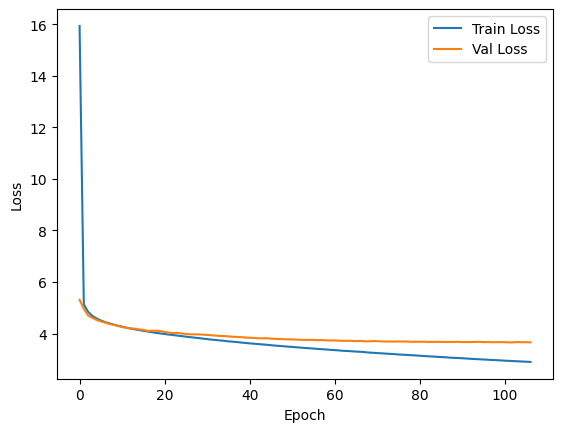

In [37]:
import matplotlib.pyplot as plt

plt.plot(train_loss_history, label="Train Loss")
plt.plot(val_loss_history, label="Val Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

In [38]:
transformer.load_state_dict(torch.load("best_model.pt"))
transformer.eval()

Transformer(
  (enc_emb): Embedding(6937, 512)
  (dec_emb): Embedding(6937, 512)
  (do): Dropout(p=0.3, inplace=False)
  (encoder): Encoder(
    (enc_layers): ModuleList(
      (0-1): 2 x EncoderLayer(
        (enc_self_attn): MultiHeadAttention(
          (W_q): Linear(in_features=512, out_features=512, bias=True)
          (W_k): Linear(in_features=512, out_features=512, bias=True)
          (W_v): Linear(in_features=512, out_features=512, bias=True)
          (linear): Linear(in_features=512, out_features=512, bias=True)
        )
        (ffn): PoswiseFeedForwardNet(
          (fc1): Linear(in_features=512, out_features=2048, bias=True)
          (fc2): Linear(in_features=2048, out_features=512, bias=True)
          (relu): ReLU()
        )
        (norm_1): LayerNorm((512,), eps=1e-06, elementwise_affine=True)
        (norm_2): LayerNorm((512,), eps=1e-06, elementwise_affine=True)
        (do): Dropout(p=0.3, inplace=False)
      )
    )
    (do): Dropout(p=0.3, inplace=False)
   

## 6. 문장 생성과 성능 평가

가장 좋은 가중치를 다시 불러온 뒤 Greedy decoding과 Beam search로 답변을 생성합니다. BLEU는 정답과의 형태소 겹침을, Perplexity는 다음 토큰 예측의 불확실성을, Distinct 점수는 생성 결과의 다양성을 확인하는 데 사용합니다.

In [39]:
from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction
from tqdm import tqdm

In [55]:
import torch

def translate(sentence, model, vocab, mecab, max_len=None):
    """
    sentence: 원본 질문 문자열 (전처리 전)
    model: 학습된 Transformer
    vocab: 공유 Vocab 인스턴스
    mecab: Mecab 인스턴스
    max_len: 없으면 전역 MAX_LEN 사용
    """
    if max_len is None:
        max_len = MAX_LEN

    model.eval()

    tokens = mecab.morphs(preprocess_sentence(sentence))
    ids = vocab.encode(tokens)

    if len(ids) > max_len:
        ids = ids[:max_len]
    else:
        ids = ids + [0] * (max_len - len(ids))

    src = torch.tensor([ids], dtype=torch.long, device=device)

    start_id = vocab.word2idx["<start>"]
    end_id = vocab.word2idx["<end>"]

    output = torch.tensor([[start_id]], dtype=torch.long, device=device)
    predicted_ids = []

    with torch.no_grad():
        for _ in range(max_len):
            enc_mask, dec_enc_mask, dec_mask = generate_masks(src, output)
            predictions, _, _, _ = model(src, output, enc_mask, dec_enc_mask, dec_mask)
            predicted_id = predictions[0, -1].softmax(dim=-1).argmax(dim=-1).item()

            if predicted_id == end_id:
                break

            predicted_ids.append(predicted_id)
            new_token = torch.tensor([[predicted_id]], dtype=torch.long, device=device)
            output = torch.cat([output, new_token], dim=1)

    result_tokens = [vocab.idx2word.get(i, "<unk>") for i in predicted_ids]

    return " ".join(result_tokens)

In [56]:
def calculate_bleu(reference, candidate, weights=(0.25, 0.25, 0.25, 0.25)):
    return sentence_bleu(
        [reference],
        candidate,
        weights=weights,
        smoothing_function=SmoothingFunction().method1,
    )


def eval_bleu_single(model, src_sentence, tgt_sentence, vocab, mecab, verbose=True):
    src_tokens = mecab.morphs(preprocess_sentence(src_sentence))
    tgt_tokens = mecab.morphs(preprocess_sentence(tgt_sentence))

    if len(src_tokens) > MAX_LEN or len(tgt_tokens) > MAX_LEN:
        return None

    # reference와 candidate를 같은 기준(mecab 형태소)으로 토큰화
    reference = tgt_tokens
    candidate = mecab.morphs(translate(src_sentence, model, vocab, mecab))

    score = calculate_bleu(reference, candidate)

    if verbose:
        print("Source Sentence: ", src_sentence)
        print("Model Prediction: ", candidate)
        print("Real: ", reference)
        print("Score: %lf\n" % score)

    return score


def eval_bleu(model, src_sentences, tgt_sentences, vocab, mecab, verbose=True):
    total_score = 0.0
    valid_count = 0

    for idx in tqdm(range(len(src_sentences))):
        score = eval_bleu_single(model, src_sentences[idx], tgt_sentences[idx], vocab, mecab, verbose)
        if score is None:
            continue
        total_score += score
        valid_count += 1

    print("Num of Sample (valid):", valid_count)
    if valid_count > 0:
        print("Total Score:", total_score / valid_count)
    else:
        print("평가 가능한 샘플이 없습니다 (모두 MAX_LEN 초과).")

In [57]:
eval_bleu(transformer, test_questions, test_answers, vocab, mecab)

  1%|          | 5/592 [00:00<00:26, 21.80it/s]

Source Sentence:  죽을거 같네
Model Prediction:  ['마음', '이', '헛헛', '하', '죠', '.']
Real:  ['나쁜', '생각', '하', '지', '마세요', '.']
Score: 0.048549

Source Sentence:  내일 시험이야
Model Prediction:  ['눈', '을', '감', '고', '명상', '을', '해', '보', '세요', '.']
Real:  ['컨디션', '조절', '하', '세요', '.']
Score: 0.044632

Source Sentence:  정말.내 자신이 싫다
Model Prediction:  ['자신', '을', '사랑', '하', '지', '마세요', '.']
Real:  ['자신', '은', '사랑', '해', '주', '세요', '.']
Score: 0.043472

Source Sentence:  이별후 네달째
Model Prediction:  ['많이', '힘들', '었', '어요', '.']
Real:  ['바쁘', '게', '살', '면서', '잊어', '가', '요', '.']
Score: 0.029487

Source Sentence:  쌍커풀 해볼까
Model Prediction:  ['같이', '해', '보', '세요', '.']
Real:  ['눈', '은', '기본', '이', '죠', '.']
Score: 0.043989



  2%|▏         | 11/592 [00:00<00:24, 24.04it/s]

Source Sentence:  내 생각 하나만 바꾸면 편할텐데.
Model Prediction:  ['마음', '이', '헛헛', '하', '죠', '.']
Real:  ['하나', '바꾸', '는', '게', '힘들', '지요', '.']
Score: 0.034557

Source Sentence:  어떻게 살아가야 할까
Model Prediction:  ['당신', '의', '삶', '을', '살', '고', '살', '아', '보', '세요', '.']
Real:  ['태연', '하', '게', '시작', '해', '보', '세요', '.']
Score: 0.093295

Source Sentence:  발 아파
Model Prediction:  ['얼른', '주무세요', '.']
Real:  ['맥주병', '같', '은', '걸로', '살살', '문질러', '주', '세요']
Score: 0.000000

Source Sentence:  썸 타는 것도 귀찮아.
Model Prediction:  ['썸', '이', '타', '는지', '확인', '해', '보', '세요', '.']
Real:  ['그냥', '사귀', '세요', '.']
Score: 0.050712

Source Sentence:  좋아하는 애랑 전화하면
Model Prediction:  ['좋', '아', '하', '는', '사람', '이', '없', '는', '걸', '알아보', '세요', '.']
Real:  ['즐거울', '거', '예요', '.']
Score: 0.017033

Source Sentence:  뿌염해야지
Model Prediction:  ['얼른', '청소', '하', '세요', '.']
Real:  ['참', '귀찮', '은', '일', '이', '죠', '.']
Score: 0.036015



  2%|▏         | 14/592 [00:00<00:23, 25.00it/s]

...

Source Sentence:  여자친구가 잘못된건 아닌데 표현이 너무 서툴러.
Model Prediction:  ['좋', '은', '사람', '만날', '수', '있', '을', '거', '예요', '.']
Real:  ['더', '좋', '은', '표현', '을', '먼저', '해', '주', '세요', '.']
Score: 0.053077

Source Sentence:  카드 다 부러뜨려 버려야겠다.
Model Prediction:  ['잘', '해', '보', '세요', '.']
Real:  ['소비', '조절', '을', '못', '하', '면', '없애', '는', '것', '도', '방법', '이', '될', '거', '예요', '.']
Score: 0.005953

Source Sentence:  드라이브 하면서 데이트 해야겠다
Model Prediction:  ['친구', '가', '보', '세요', '.']
Real:  ['야경', '좋', '은', '곳', '으로', '가', '보', '세요', '.']
Score: 0.300484

Source Sentence:  너무 힘들어서 정말 너무 힘들어
Model Prediction:  ['많이', '힘들', '었', '어요', '.']
Real:  ['언제', '든', '더', '좋', '은', '사람', '만날', '수', '있', '어요', '.']
Score: 0.034222

Source Sentence:  그게 잘 안되네.
Model Prediction:  ['사랑', '은', '변하', '는', '게', '아니', '에요', '.']
Real:  ['마음', '이', '쉽', '지', '않', '죠', '.']
Score: 0.027776



100%|█████████▉| 590/592 [00:23<00:00, 16.38it/s]

Source Sentence:  짝사랑 하면서 내가 초라하게 느껴져.
Model Prediction:  ['그', '사람', '도', '그', '사람', '을', '힘들', '어', '하', '지', '않', '아요', '.']
Real:  ['나', '만', '좋', '아', '한다는', '사실', '이', '그렇게', '만들', '어요', '.']
Score: 0.015537

Source Sentence:  우리 둘이 모은 돈으로 결혼해야 돼
Model Prediction:  ['사랑', '은', '당신', '만', '의', '인생', '이', '주인공', '이', '주인공', '이', '주인공', '이', '주인공', '이', '주인공', '이', '주인공', '이', '주인공', '이', '주인공']
Real:  ['그게', '정상', '인', '거', '예요', '.']
Score: 0.000000

Source Sentence:  보이스피싱 전화왔어
Model Prediction:  ['청소', '하', '세요', '.']
Real:  ['신고', '하', '세요', '.']
Score: 0.397635

Source Sentence:  전학 걱정된다?
Model Prediction:  ['그럴', '수', '있', '어요', '.']
Real:  ['걱정', '하', '지', '마세요', '.', '잘', '할', '거', '예요', '.']
Score: 0.019766



100%|██████████| 592/592 [00:23<00:00, 25.17it/s]

Source Sentence:  그 사람이 나 안 좋아하는 거 같아
Model Prediction:  ['좋', '아', '하', '는', '사람', '과', '대상', '이', '에요', '.']
Real:  ['슬픈', '이야기', '네요', '.']
Score: 0.021105

Num of Sample (valid): 589
Total Score: 0.03927099308643584


In [58]:
import torch
import torch.nn.functional as F

def calc_prob(src_ids, tgt_ids, model):
    # 마스크 생성 (PyTorch 버전)
    enc_padding_mask, combined_mask, dec_padding_mask = generate_masks(src_ids, tgt_ids)

    # 모델 forward pass
    predictions, enc_attns, dec_attns, dec_enc_attns = model(
        src_ids,
        tgt_ids,
        enc_padding_mask,
        combined_mask,
        dec_padding_mask
    )

    # 마지막 차원에 대해 softmax 적용하여 확률값 계산
    return F.softmax(predictions, dim=-1)

In [59]:
import numpy as np
import torch


def beam_search_decoder(sentence, src_len, tgt_len, model, vocab, mecab, beam_size):
    tokens = vocab.encode(mecab.morphs(preprocess_sentence(sentence)))
    tokens = tokens[:src_len]

    padded = np.zeros((1, src_len), dtype=np.int64)
    padded[0, :len(tokens)] = tokens
    src_in = torch.tensor(padded, dtype=torch.long, device=device)

    start_id = vocab.word2idx["<start>"]
    end_id = vocab.word2idx["<end>"]
    pred_cache = np.zeros((beam_size * beam_size, tgt_len), dtype=np.int64)
    pred_tmp = np.zeros((beam_size, tgt_len), dtype=np.int64)
    eos_flag = np.zeros((beam_size,), dtype=np.int64)
    scores = np.ones((beam_size,), dtype=np.float32)
    pred_tmp[:, 0] = start_id

    dec_in = torch.tensor(pred_tmp[0, :1], dtype=torch.long, device=device).unsqueeze(0)
    prob = calc_prob(src_in, dec_in, model)[0, -1].detach().cpu().numpy()

    for seq_pos in range(1, tgt_len):
        score_cache = np.ones((beam_size * beam_size,), dtype=np.float32)

        for branch_idx in range(beam_size):
            cache_pos = branch_idx * beam_size
            score_cache[cache_pos:cache_pos + beam_size] = scores[branch_idx]
            pred_cache[cache_pos:cache_pos + beam_size, :seq_pos] = pred_tmp[branch_idx, :seq_pos]

        for branch_idx in range(beam_size):
            cache_pos = branch_idx * beam_size
            if seq_pos != 1:
                dec_in = torch.tensor(pred_cache[branch_idx, :seq_pos], dtype=torch.long, device=device).unsqueeze(0)
                prob = calc_prob(src_in, dec_in, model)[0, -1].detach().cpu().numpy()

            for beam_idx in range(beam_size):
                max_idx = np.argmax(prob)
                score_cache[cache_pos + beam_idx] *= prob[max_idx]
                pred_cache[cache_pos + beam_idx, seq_pos] = max_idx
                prob[max_idx] = -1

        for beam_idx in range(beam_size):
            if eos_flag[beam_idx] == -1:
                continue
            max_idx = np.argmax(score_cache)
            prediction = pred_cache[max_idx, :seq_pos + 1].copy()
            pred_tmp[beam_idx, :seq_pos + 1] = prediction
            scores[beam_idx] = score_cache[max_idx]
            score_cache[max_idx] = -1

            if prediction[-1] == end_id:
                eos_flag[beam_idx] = -1

    pred = []
    for long_pred in pred_tmp:
        try:
            eos_idx = list(long_pred).index(end_id)
        except ValueError:
            eos_idx = tgt_len - 1
        pred.append(long_pred[:eos_idx + 1].tolist())

    return pred

In [60]:
from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction


def calculate_bleu(reference, candidate, weights=[0.25, 0.25, 0.25, 0.25]):
    return sentence_bleu([reference],
                          candidate,
                          weights=weights,
                          smoothing_function=SmoothingFunction().method1)


def beam_bleu(reference, ids, vocab, mecab):
    # 기준 문장을 candidate와 동일한 기준(mecab 형태소)으로 토큰화
    reference_tokens = mecab.morphs(preprocess_sentence(reference))

    total_score = 0.0
    num_candidates = len(ids)
    if num_candidates == 0:
        return 0.0

    for candidate_ids in ids:
        # vocab은 이미 mecab 형태소 단위이므로, id -> 토큰 매핑만 하면 됩니다.
        # SentencePiece decode_ids처럼 subword를 합치는 과정이 필요 없습니다
        candidate_tokens = [vocab.idx2word.get(i, "<unk>") for i in candidate_ids]
        # <start> 토큰이 섞여 있다면 제거 (beam_search_decoder는 <start>부터 채워 넣으므로)
        candidate_tokens = [t for t in candidate_tokens if t not in ("<start>", "<end>", "<pad>")]

        score = calculate_bleu(reference_tokens, candidate_tokens)

        print(f"Reference: {reference_tokens}")
        print(f"Candidate: {candidate_tokens}")
        print(f"BLEU: {score}")

        total_score += score

    return total_score / num_candidates

In [61]:
import math
val_perplexity = math.exp(val_loss)
print(f"Val Perplexity: {val_perplexity:.2f}")

Val Perplexity: 38.74


In [67]:
def distinct_n(sentences, n):
    all_ngrams = []
    for tokens in sentences:
        all_ngrams.extend([tuple(tokens[i:i+n]) for i in range(len(tokens) - n + 1)])
    if not all_ngrams:
        return 0.0
    return len(set(all_ngrams)) / len(all_ngrams)

# test_questions 전체에 대해 translate() 돌린 결과를 모아서
generated = [mecab.morphs(translate(q, transformer, vocab, mecab)) for q in test_questions]

# Distinct-1 : 단어(형태소) 다양성
print("Distinct-1:", distinct_n(generated, 1))
# Distinct-2 : 단어 2개 조합의 다양성
print("Distinct-2:", distinct_n(generated, 2))

Distinct-1: 0.08298572996706916
Distinct-2: 0.20741862225586677


In [63]:
import random


def show_random_translations(n=10, seed=None):
    if seed is not None:
        random.seed(seed)

    indices = random.sample(range(len(test_questions)), n)
    for idx in indices:
        src = test_questions[idx]
        ref = test_answers[idx]
        pred = translate(src, transformer, vocab, mecab)
        print(f"[{idx}] 질문: {src}")
        print(f"     정답: {ref}")
        print(f"     예측: {pred}")
        print()


def show_beam_translations(indices, beam_size=5):
    for idx in indices:
        src = test_questions[idx]
        ref = test_answers[idx]
        ids = beam_search_decoder(src, MAX_LEN, MAX_LEN, transformer, vocab, mecab, beam_size=beam_size)
        print(f"[{idx}] 질문: {src}")
        print(f"     정답: {ref}")
        bleu = beam_bleu(ref, ids, vocab, mecab)
        print(f"     평균 BLEU: {bleu:.4f}")
        print("-" * 60)


def try_custom_sentence(sentence, beam_size=5):
    print(f"입력: {sentence}")
    print(f"Greedy: {translate(sentence, transformer, vocab, mecab)}")

    ids = beam_search_decoder(sentence, MAX_LEN, MAX_LEN, transformer, vocab, mecab, beam_size=beam_size)
    for candidate_ids in ids:
        tokens = [vocab.idx2word.get(i, "<unk>") for i in candidate_ids]
        tokens = [token for token in tokens if token not in ("<start>", "<end>", "<pad>")]
        print(f"Beam 후보: {' '.join(tokens)}")

In [64]:
show_random_translations(n=10, seed=42)

[114] 질문: 썸남 꿈 꿨어.
     정답: 그분 생각을 많이 했나 봐요. 곧 좋은 소식이 들리려고 하는 것 아닐까요?
     예측: 좋 은 선택 이 길 바라 요 .

[25] 질문: 눈물 나올라 그래
     정답: 울어도 돼요.
     예측: 마음 이 복잡 하 겠 어요 .

[281] 질문: 이별. 냉정해진다
     정답: 성장에는 고통이 따르나봐요.
     예측: 이별 은 항상 힘들 게 하 죠 .

[250] 질문: 문화센터라도 가야겠다.
     정답: 다양하게 배우면 좋죠.
     예측: 건강 에 좋 죠 .

[228] 질문: 6년의시간과 6일간의 헤어짐 이제보내주려합니다
     정답: 힘들겠지만 천천히 보내주세요.
     예측: 마음 이 허전 하 겠 어요 .

[142] 질문: 여자친구가 소극적이야.
     정답: 조금이라도 적극적이면 큰 리액션을 보내주세요.
     예측: 서로 에게 의지 해 보 세요 .

[104] 질문: 예랑이가 마마보이인듯
     정답: 남자는 여자하기 나름이래요. 변화시켜 보세요.
     예측: 저 도 데려가 세요 .

[558] 질문: 휴지도 떨어졌네.
     정답: 생활용품이 은근 많이 들어가요.
     예측: 너무 신경 쓰 지 마세요 .

[89] 질문: 정장 사야겠지
     정답: 사면 요긴하긴 할 거 같아요.
     예측: 잘 하 면 좋 을 거 예요 .

[432] 질문: 스터디 하는데 괜찮은 사람 있어.
     정답: 하라는 공부는 안하고!
     예측: 공부 는 안 하 는 게 쉽 지 않 죠 .



In [65]:
show_beam_translations([0, 1, 2, 5, 10])

[0] 질문: 죽을거 같네
     정답: 나쁜 생각 하지 마세요.
Reference: ['나쁜', '생각', '하', '지', '마세요', '.']
Candidate: ['마음', '이', '헛헛', '하', '죠', '.']
BLEU: 0.048549177170732344
Reference: ['나쁜', '생각', '하', '지', '마세요', '.']
Candidate: ['많이', '이', '헛헛', '하', '죠', '.']
BLEU: 0.048549177170732344
Reference: ['나쁜', '생각', '하', '지', '마세요', '.']
Candidate: ['이제', '이', '헛헛', '하', '죠', '.']
BLEU: 0.048549177170732344
Reference: ['나쁜', '생각', '하', '지', '마세요', '.']
Candidate: ['마음', '의', '헛헛', '하', '죠', '.']
BLEU: 0.048549177170732344
Reference: ['나쁜', '생각', '하', '지', '마세요', '.']
Candidate: ['마음', '에', '헛헛', '하', '죠', '.']
BLEU: 0.048549177170732344
     평균 BLEU: 0.0485
------------------------------------------------------------
[1] 질문: 내일 시험이야
     정답: 컨디션 조절 하세요.
Reference: ['컨디션', '조절', '하', '세요', '.']
Candidate: ['눈', '을', '감', '고', '명상', '을', '해', '보', '세요', '.']
BLEU: 0.0446323613785333
Reference: ['컨디션', '조절', '하', '세요', '.']
Candidate: ['눈', '을', '감', '고', '차분', '을', '해', '보', '세요', '.']
BLEU: 0.044632361378533

In [66]:
try_custom_sentence("오늘 너무 힘들어요")

입력: 오늘 너무 힘들어요
Greedy: 꿈 이 웬수 네요 .
Beam 후보: 꿈 이 웬수 네요 .
Beam 후보: 혼자 이 웬수 네요 .
Beam 후보: 꿈 에 웬수 네요 .
Beam 후보: 혼자 에 웬수 네요 .
Beam 후보: 꿈 이 웬수 죠 .


## 결과 해석

## 1. 학습 과정에서 겪은 주요 어려움과 해결

### 사전학습 Word2Vec 모델 로딩 실패
Kyubyong/wordvectors의 `ko.bin`이 아주 오래된 gensim 버전(2017년경)으로 저장된 파일이라 최신 gensim에서 `Word2Vec.load()`가 `AttributeError`/`ModuleNotFoundError`로 실패했습니다.

**해결**: 별도의 구버전 gensim에서 모델을 로드한 뒤 `save_word2vec_format()`(범용 바이너리 포맷)으로 재저장하고 최신 gensim에서는 `KeyedVectors.load_word2vec_format()`으로 불러오도록 변환했습니다.

### Loss가 수천 단위로 나옴
학습이 진행돼도 loss가 수백~수천 단위로 나왔습니다. 원인을 좁힌 결과 두 가지 구조적 버그가 겹쳐 있었습니다.
- Pre-LN Transformer 구조인데 모든 레이어를 통과한 뒤의 최종 LayerNorm이 누락되어 있어 residual 값이 레이어를 거칠수록 정규화되지 않고 커짐
- `shared_fc`(Embedding-출력층 weight tying) 구조인데 `nn.Embedding`의 기본 초기화 표준편차(1.0)가 너무 커서 결합 시 logit이 폭발함

**해결**: `Encoder`/`Decoder`에 마지막 LayerNorm을 추가하고 Embedding을 `d_model^-0.5` 표준편차로 명시적으로 재초기화했습니다. 그 결과 초기 loss가 356 → 12.6으로 학습 후 최종 loss도 정상 범위로 안정화됐습니다.

### 소규모 데이터로 인한 과적합 우려
데이터가 1만 개 안팎으로 적어 오래 학습시키면 과적합될 위험이 있었습니다.

**해결**: 별도의 validation 셋을 분리하고 validation loss가 더 이상 개선되지 않으면 멈추는 Early Stopping과 최고 성능 체크포인트 저장을 구현했습니다.

---

## 2. 평가지표가 의미하는 것과 해석 방법

| 지표 | 의미 | 해석 방법 |
|---|---|---|
| **Perplexity** | `exp(loss)`. "다음 토큰을 예측할 때 평균적으로 몇 개 후보 사이에서 헷갈리는가" | 낮을수록 좋음. 소규모 한국어 챗봇 기준 20~60 정도면 정상적으로 학습된 편 |
| **BLEU** | 모델 출력과 정답 문장의 n-gram 일치도 | 챗봇은 정답이 여러 개일 수 있는데 reference가 하나뿐이라 구조적으로 낮게 나오는 게 정상 |
| **Distinct-1/2** | 생성 문장들에서 unique한 unigram/bigram 비율 | 낮으면 뻔한 답변 반복, 0.2 이상이면 준수한 편 |

---

## 3. 결과 해석

**최종 지표**
- Val Perplexity: **38.74** → 소규모 데이터로 처음부터 학습한 한국어 챗봇 기준 준수한 수준
- Distinct-1: **0.0829857**, Distinct-2: **0.2074186** → 반복적인 정형 답변이 아니라 상황별로 다른 표현을 생성하는 편
- BLEU: **0.039** → 절대값은 낮지만 챗봇 태스크 특성상 예상되는 범위

**정성 평가**
- `"같이 가 보세요."`처럼 질문과 정답이 정확히 겹치는 경우 BLEU가 1.0에 가깝게 나오기도 했고 대부분은 정답과 문장은 다르지만 문법적으로 완결되고 맥락은 어느 정도 유지하는 답변을 생성했습니다 (`"건강에 좋죠."`, `"마음이 허전하겠어요."` 등)
- beam 5개 후보가 한두 단어만 바뀐 채 서로 유사한 경우가 많아 여전히 표현 다양성 면에서는 개선 여지가 있습니다.